<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%202/Week_2_Lecture_6_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=hBMOK2YCpXc) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%202/DL4CV_Week02_Part06.pdf)

In [ ]:
# Week 2, Lecture 6: Other feature spaces
from IPython.display import HTML, display

VIDEO_ID = "hBMOK2YCpXc"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 2, Lecture 6: Other Feature Spaces

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§2.6 Other Feature Spaces**.

**What you will learn**

- Describe shape with **Shape Context**.
- Detect stable regions with **MSER**.
- Build the **HOG** descriptor and its pyramidal variant **PHOG**.
- Encode texture with **Local Binary Patterns (LBP)**.
- Compare these detectors and descriptors, and choose between them for a task.

**Contents**
1. Shape Context
2. Maximally Stable Extremal Regions (MSER)
3. Histogram of Oriented Gradients (HOG)
4. Pyramidal HOG (PHOG)
5. Local Binary Patterns (LBP)
6. Comparing feature detectors

**How to run**  Runs on Colab or a local Jupyter, CPU only. Needs `opencv-python` alongside `scikit-image` and `scipy`; Colab ships all three. Run the setup cell first, then go top to bottom.

## Review

Earlier lectures built *detectors* that fire at interesting locations: Harris corners, and blob detectors with a characteristic scale. A detector only says where; a **descriptor** says what, by turning a patch, region, or shape into a fixed-length vector that can be matched or fed to a classifier.

This lecture surveys the hand-crafted feature spaces that dominated recognition before deep learning:
- **shape** descriptors that compare object outlines (Shape Context),
- **region** descriptors from stable thresholded blobs (MSER),
- **gradient** descriptors from local orientation histograms (HOG, PHOG),
- **texture** descriptors from local intensity patterns (LBP).

Each one is a different answer to the same question: what is a good, invariant summary of local image content?

## Setup

Everything runs offline on images bundled with `scikit-image` or generated synthetically. The `load_gray` and `show` helpers are shared across sections.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment
from skimage import data, util, color, feature
from skimage.measure import find_contours
import cv2

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def load_gray(image):
    return color.rgb2gray(image) if image.ndim == 3 else util.img_as_float(image)

def show(ax, im, title='', cmap='gray'):
    ax.imshow(im, cmap=cmap); ax.set_title(title); ax.axis("off")

## 1. Shape Context

Shape Context describes a shape by how the rest of its outline is arranged around each boundary point. Sample $N$ points on the contour. For a point $p_i$, take the vectors to all other points and drop them into a **log-polar histogram**: bins are coarse in radius (log spacing) and uniform in angle, so nearby structure is measured finely and distant structure coarsely.

$$
h_i(k) = \#\{\, q \neq p_i : (q - p_i) \in \text{bin } k \,\}, \qquad k = 1, \dots, 60 .
$$

Two properties follow from the construction:
- **translation invariance**, because only relative vectors are used,
- **scale invariance**, by normalizing the radii by their mean before binning.

To compare a point $i$ on one shape with a point $j$ on another, the histograms are matched with a chi-square cost

$$
C_{ij} = \frac{1}{2} \sum_{k=1}^{K} \frac{\big[\, h_i(k) - h_j(k) \,\big]^2}{h_i(k) + h_j(k)} .
$$

The best one-to-one correspondence minimizes the total cost, and a low total cost means the shapes match.

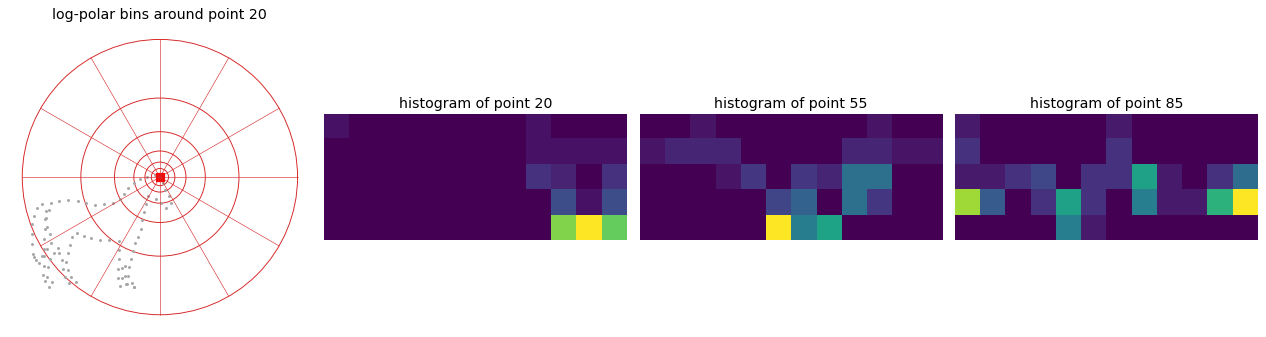

In [2]:
def sample_contour(mask, n_pts):
    c = max(find_contours(mask.astype(float), 0.5), key=len)   # longest boundary
    idx = np.linspace(0, len(c) - 1, n_pts).astype(int)
    return c[idx][:, ::-1]                                     # (row, col) -> (x, y)

def shape_context(pts, n_r=5, n_theta=12, r_min=0.125, r_max=2.0):
    d = pts[:, None, :] - pts[None, :, :]                      # vectors i -> j
    r = np.hypot(d[..., 0], d[..., 1])
    r = r / r[r > 0].mean()                                    # normalize radii -> scale invariant
    theta = np.arctan2(d[..., 1], d[..., 0]) % (2 * np.pi)
    r_edges = np.logspace(np.log10(r_min), np.log10(r_max), n_r + 1)
    r_bin = np.digitize(r, r_edges)                            # 0 (too near) .. n_r+1 (too far)
    t_bin = np.minimum((theta / (2 * np.pi) * n_theta).astype(int), n_theta - 1)
    N = len(pts); H = np.zeros((N, n_r, n_theta))
    for i in range(N):
        keep = (r_bin[i] >= 1) & (r_bin[i] <= n_r); keep[i] = False
        np.add.at(H[i], (r_bin[i][keep] - 1, t_bin[i][keep]), 1)
    H = H.reshape(N, -1)
    return H / (H.sum(1, keepdims=True) + 1e-8)                # per-point normalized histogram

pts = sample_contour(data.horse(), 100)
n_r, n_theta = 5, 12
H = shape_context(pts, n_r, n_theta)

d = pts[:, None, :] - pts[None, :, :]
mean_r = np.hypot(d[..., 0], d[..., 1])
mean_r = mean_r[mean_r > 0].mean()
edges_px = np.logspace(np.log10(0.125), np.log10(2.0), n_r + 1) * mean_r

ref = 20
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].plot(pts[:, 0], pts[:, 1], '.', ms=3, color='0.65')
ax[0].plot(*pts[ref], 'rs', ms=7)
for rad in edges_px:                                          # log-spaced radial bin edges
    ax[0].add_patch(plt.Circle(pts[ref], rad, fill=False, color='tab:red', lw=0.8))
for a in np.linspace(0, 2 * np.pi, n_theta, endpoint=False):  # angular bin edges
    ax[0].plot([pts[ref, 0], pts[ref, 0] + edges_px[-1] * np.cos(a)],
               [pts[ref, 1], pts[ref, 1] + edges_px[-1] * np.sin(a)], color='tab:red', lw=0.5)
ax[0].set_aspect('equal'); ax[0].invert_yaxis(); ax[0].axis('off')
ax[0].set_title(f'log-polar bins around point {ref}')
for k, i in enumerate([ref, 55, 85]):
    show(ax[k + 1], H[i].reshape(n_r, n_theta), f'histogram of point {i}', cmap='viridis')
plt.tight_layout(); plt.show()

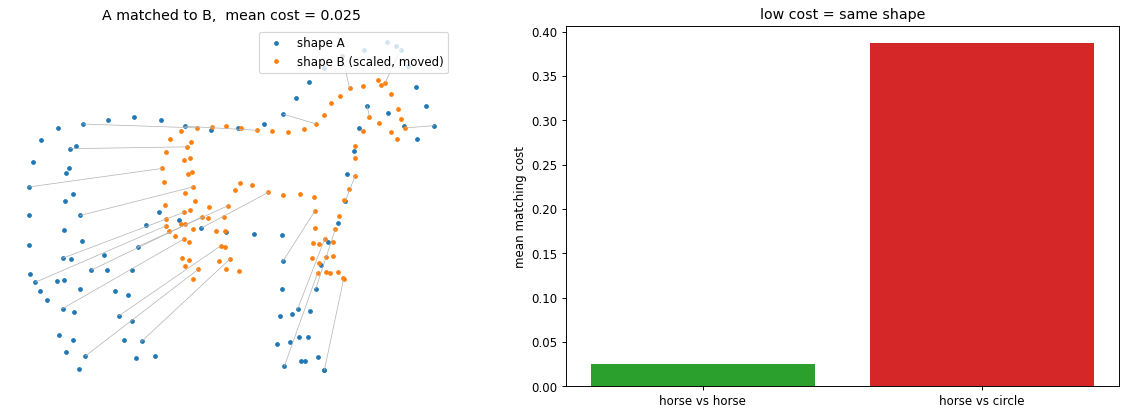

In [3]:
def sc_cost(HA, HB):                                          # chi-square between all point pairs
    a, b = HA[:, None, :], HB[None, :, :]
    return 0.5 * (((a - b) ** 2) / (a + b + 1e-8)).sum(-1)

def match(HA, HB):
    C = sc_cost(HA, HB)
    ri, ci = linear_sum_assignment(C)                         # optimal one-to-one correspondence
    return ci, C[ri, ci].mean()

A = sample_contour(data.horse(), 100)
B = A * 0.6 + [130, 40] + np.random.normal(0, 1.2, A.shape)   # same horse: scaled, moved, jittered

circ = np.zeros(data.horse().shape, bool)                     # a different shape for contrast
yy, xx = np.mgrid[:circ.shape[0], :circ.shape[1]]
circ[(xx - 200) ** 2 + (yy - 160) ** 2 < 90 ** 2] = True
C_pts = sample_contour(circ, 100)

HA, HB, HC = shape_context(A), shape_context(B), shape_context(C_pts)
corr, cost_same = match(HA, HB)
_, cost_diff = match(HA, HC)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(A[:, 0], A[:, 1], 'o', ms=3, color='tab:blue', label='shape A')
ax[0].plot(B[:, 0], B[:, 1], 'o', ms=3, color='tab:orange', label='shape B (scaled, moved)')
for i in range(0, 100, 4):
    ax[0].plot([A[i, 0], B[corr[i], 0]], [A[i, 1], B[corr[i], 1]], color='0.7', lw=0.6)
ax[0].invert_yaxis(); ax[0].set_aspect('equal'); ax[0].legend(loc='upper right')
ax[0].set_title(f'A matched to B,  mean cost = {cost_same:.3f}'); ax[0].axis('off')
ax[1].bar(['horse vs horse', 'horse vs circle'], [cost_same, cost_diff],
          color=['tab:green', 'tab:red'])
ax[1].set_ylabel('mean matching cost'); ax[1].set_title('low cost = same shape')
plt.tight_layout(); plt.show()

## 2. Maximally Stable Extremal Regions (MSER)

MSER detects blobs by watching how thresholded regions behave as the threshold moves. Sweep a gray level $g$ from low to high and keep the connected components of the thresholded image. These are **extremal regions**: every pixel inside is brighter (or darker) than every pixel on the boundary. As $g$ changes, regions are born, grow, and merge, which nests them in a tree.

A region is **stable** if its area barely changes over a range of thresholds. With region areas $|R^g|$ at level $g$ and a small buffer $\Delta$,

$$
\Psi(R^g) = \frac{|R^{g-\Delta}| - |R^{g+\Delta}|}{|R^g|} .
$$

The regions where $\Psi$ is a local minimum are the MSERs: they persist across many thresholds, which makes them repeatable under viewpoint and lighting changes. The descriptor is then the region itself (its shape, or a normalized patch).

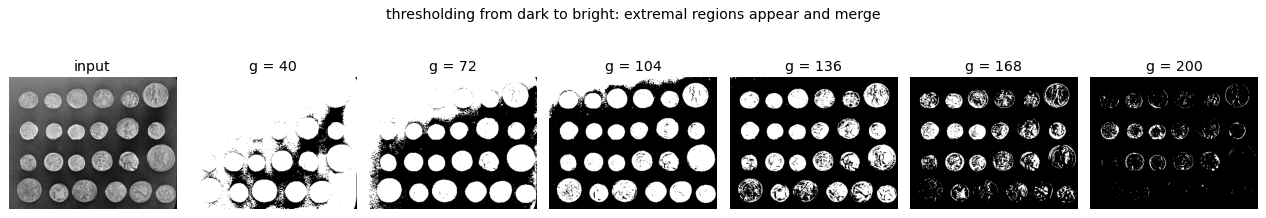

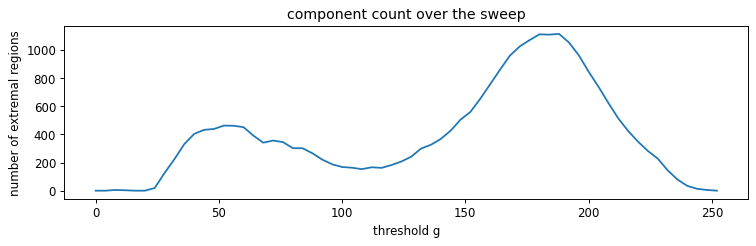

In [4]:
img = util.img_as_ubyte(data.coins())

levels = np.linspace(40, 200, 6).astype(int)
fig, ax = plt.subplots(1, 7, figsize=(15, 3))
show(ax[0], img, 'input')
for k, g in enumerate(levels):
    show(ax[k + 1], img >= g, f'g = {g}')                     # bright extremal regions at level g
fig.suptitle('thresholding from dark to bright: extremal regions appear and merge')
plt.tight_layout(); plt.show()

gs = np.arange(0, 256, 4)
n_comp = [ndi.label(img >= g)[1] for g in gs]                 # connected components at each level
plt.figure(figsize=(9, 3))
plt.plot(gs, n_comp); plt.xlabel('threshold g'); plt.ylabel('number of extremal regions')
plt.title('component count over the sweep'); plt.tight_layout(); plt.show()

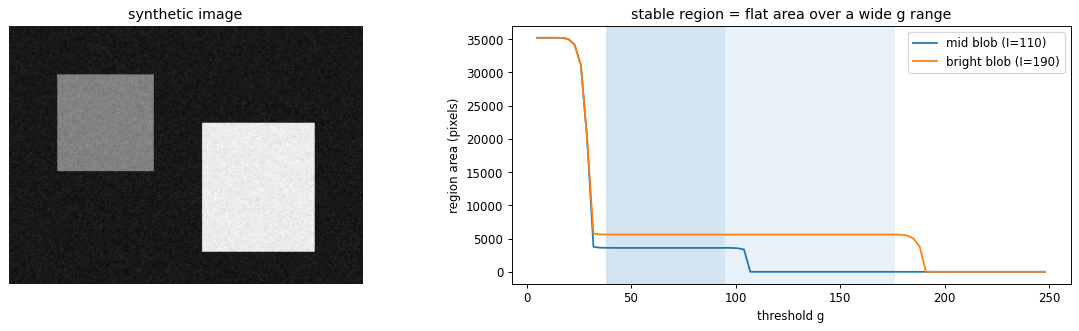

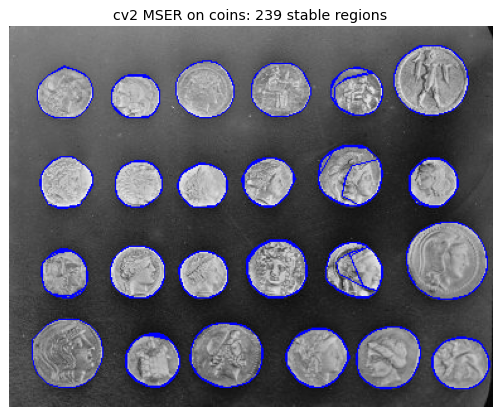

In [5]:
def region_area(im, seed, g):                                 # area of the region containing seed
    lab, _ = ndi.label(im >= g)
    lid = lab[seed]
    return (lab == lid).sum() if lid > 0 else 0

syn = np.full((160, 220), 30, np.float64)                     # two uniform blobs on a dark background
syn[30:90, 30:90]    = 110
syn[60:140, 120:190] = 190
syn = np.clip(syn + np.random.normal(0, 4, syn.shape), 0, 255)

seeds = {'mid blob (I=110)': (60, 60), 'bright blob (I=190)': (100, 155)}
gs = np.arange(5, 251, 3)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
show(ax[0], syn, 'synthetic image')
for name, seed in seeds.items():
    area = np.array([region_area(syn, seed, g) for g in gs], float)
    ax[1].plot(gs, area, label=name)
    D = 2                                                     # normalized area change over a buffer
    q = np.full_like(area, np.nan)
    q[D:-D] = np.abs(area[:-2 * D] - area[2 * D:]) / (area[D:-D] + 1e-8)
    stable = (q < 0.05) & (area > 50) & (area < 0.5 * syn.size)
    if stable.any():
        ax[1].axvspan(gs[stable][0], gs[stable][-1], alpha=0.10)   # shaded = stable plateau
ax[1].set_xlabel('threshold g'); ax[1].set_ylabel('region area (pixels)')
ax[1].set_title('stable region = flat area over a wide g range'); ax[1].legend()
plt.tight_layout(); plt.show()

gray = util.img_as_ubyte(data.coins())                        # what a library MSER returns
mser = cv2.MSER_create(delta=6, min_area=200, max_area=8000)
regions, _ = mser.detectRegions(gray)
canvas = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for r in regions:
    cv2.polylines(canvas, [cv2.convexHull(r.reshape(-1, 1, 2))], True, (255, 0, 0), 1)
fig, ax = plt.subplots(figsize=(8, 5))
show(ax, canvas[..., ::-1], f'cv2 MSER on coins: {len(regions)} stable regions')
plt.tight_layout(); plt.show()

## 3. Histogram of Oriented Gradients (HOG)

HOG summarizes local shape by the distribution of gradient orientations. The steps are:
1. Compute the gradient at every pixel, giving magnitude and orientation.
2. Split the image into small **cells** (say $8 \times 8$ pixels).
3. In each cell build a histogram of orientations, where every pixel votes for its orientation bin **weighted by its gradient magnitude**.
4. Group cells into overlapping **blocks** and normalize each block, which cancels local changes in contrast and illumination.
5. Concatenate all block histograms into the final descriptor.

Orientations are usually folded to $[0^\circ, 180^\circ)$ so that opposite gradient directions share a bin. The histogram keeps *which orientations are present* while discarding *exactly where*, which gives tolerance to small deformations. HOG was the standard for pedestrian detection before deep learning.

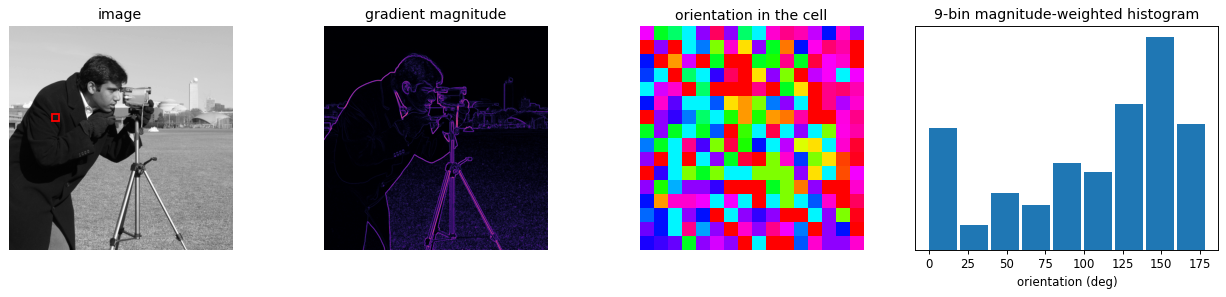

In [6]:
img = util.img_as_float(data.camera())
gy, gx = np.gradient(img)
mag = np.hypot(gx, gy)
ori = np.rad2deg(np.arctan2(gy, gx)) % 180                    # fold to [0, 180)

cy, cx, s = 200, 100, 16                                      # one 16x16 cell over a strong edge
cell_mag, cell_ori = mag[cy:cy + s, cx:cx + s], ori[cy:cy + s, cx:cx + s]
hist, edges = np.histogram(cell_ori, bins=9, range=(0, 180), weights=cell_mag)

fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
show(ax[0], img, 'image')
ax[0].add_patch(plt.Rectangle((cx, cy), s, s, ec='red', fc='none', lw=1.5))
show(ax[1], mag, 'gradient magnitude', cmap='magma')
show(ax[2], cell_ori, 'orientation in the cell', cmap='hsv')
ax[3].bar(edges[:-1], hist, width=18, align='edge', color='tab:blue')
ax[3].set_title('9-bin magnitude-weighted histogram')
ax[3].set_xlabel('orientation (deg)'); ax[3].set_yticks([])
plt.tight_layout(); plt.show()

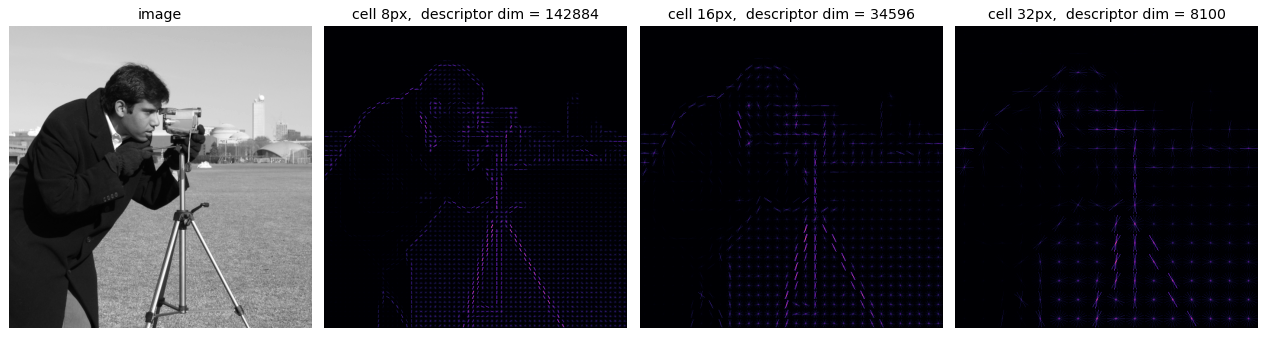

In [7]:
from skimage.feature import hog

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(ax[0], img, 'image')
for k, ppc in enumerate([(8, 8), (16, 16), (32, 32)]):
    feat, hog_img = hog(img, orientations=9, pixels_per_cell=ppc, cells_per_block=(2, 2),
                        visualize=True, feature_vector=True)
    show(ax[k + 1], hog_img, f'cell {ppc[0]}px,  descriptor dim = {feat.size}', cmap='magma')
plt.tight_layout(); plt.show()

## 4. Pyramidal HOG (PHOG)

HOG on one grid loses the coarse spatial layout of the shape. PHOG adds it back with a spatial pyramid. At level $l$ the image is divided into $2^l \times 2^l$ cells, an orientation histogram is taken over each cell, and the histograms from every level are concatenated:

$$
\text{PHOG} = \big[\; H^{(0)} \;\|\; H^{(1)} \;\|\; \dots \;\|\; H^{(L)} \;\big] .
$$

Level $0$ is a single global histogram; deeper levels record where the oriented edges sit. The concatenation captures the spatial arrangement of gradients better than a flat HOG, at the cost of a longer descriptor. With $B$ orientation bins the length is $B \sum_{l=0}^{L} 4^{l}$.

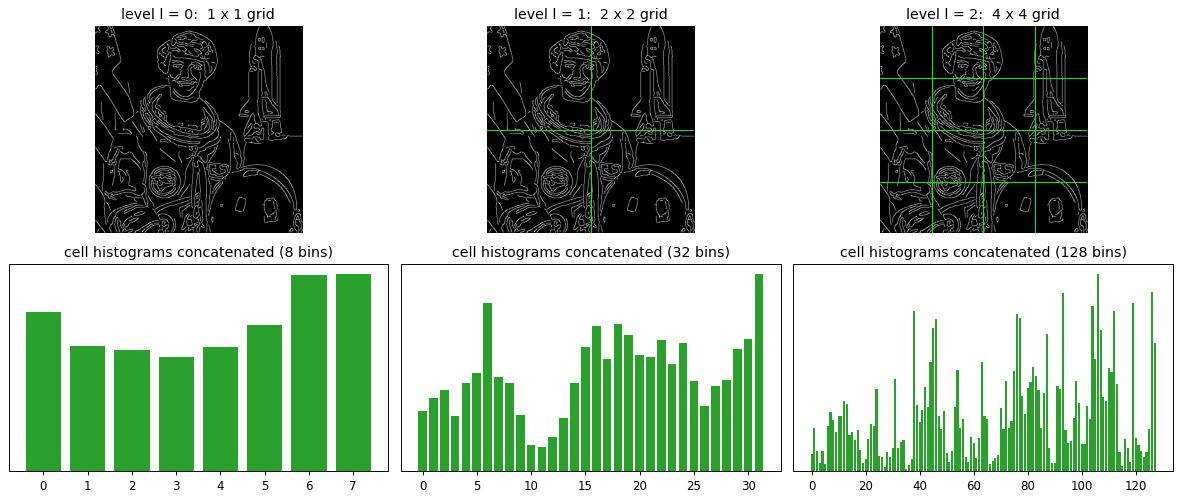

PHOG descriptor length (levels 0-2, 8 bins): 168


In [8]:
img = load_gray(data.astronaut())
edges = feature.canny(img, sigma=2)                           # PHOG histograms orientations on edges
gy, gx = np.gradient(img)
ori = np.rad2deg(np.arctan2(gy, gx)) % 180
mag = np.hypot(gx, gy) * edges                                # weight only edge pixels

def level_hist(ori, mag, l, bins=8):
    n = 2 ** l; Hh, Ww = ori.shape; feats = []
    for by in range(n):
        for bx in range(n):
            ys, xs = by * Hh // n, bx * Ww // n
            ye, xe = (by + 1) * Hh // n, (bx + 1) * Ww // n
            h, _ = np.histogram(ori[ys:ye, xs:xe], bins=bins, range=(0, 180),
                                weights=mag[ys:ye, xs:xe])
            feats.append(h)
    return np.concatenate(feats)

fig, ax = plt.subplots(2, 3, figsize=(14, 6))
for l in range(3):
    show(ax[0, l], edges, f'level l = {l}:  {2 ** l} x {2 ** l} grid')
    n = 2 ** l
    for g in range(1, n):                                     # draw the grid lines
        ax[0, l].axhline(g * img.shape[0] / n, color='lime', lw=0.8)
        ax[0, l].axvline(g * img.shape[1] / n, color='lime', lw=0.8)
    h = level_hist(ori, mag, l)
    ax[1, l].bar(range(len(h)), h, color='tab:green')
    ax[1, l].set_title(f'cell histograms concatenated ({len(h)} bins)'); ax[1, l].set_yticks([])
plt.tight_layout(); plt.show()

phog = np.concatenate([level_hist(ori, mag, l) for l in range(3)])
print('PHOG descriptor length (levels 0-2, 8 bins):', phog.size)

## 5. Local Binary Patterns (LBP)

LBP describes texture by comparing each pixel to its neighbors. For a pixel and its 8 neighbors, threshold each neighbor against the center: $1$ if it is greater or equal, $0$ otherwise. Reading the 8 bits in a fixed order gives a number in $[0, 255]$, the LBP code of that pixel.

$$
\text{LBP}(c) = \sum_{p=0}^{P-1} s\big( g_p - g_c \big)\, 2^{p}, \qquad
s(x) = \begin{cases} 1 & x \geq 0 \\ 0 & x < 0 \end{cases}
$$

The code is a tiny signature of the local pattern (edge, corner, flat, spot). A texture is described by the **histogram of codes** over a region, and an image by concatenating the histograms of its cells. Two useful generalizations:
- a circle of $P$ points at radius $R$, with bilinear interpolation when a point falls between pixels, so different scales of texture can be captured,
- **uniform** patterns, which keep only codes with at most two bit transitions (the common edge and corner patterns) and pool the rest, shrinking the histogram.

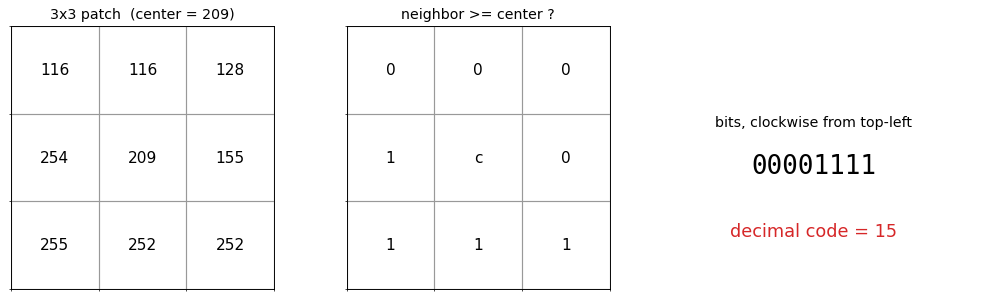

binary 00001111 -> decimal 15   (slide: 00001111 = 15)


In [9]:
patch = np.array([[116, 116, 128],
                  [254, 209, 155],
                  [255, 252, 252]])
c = patch[1, 1]
order = [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (1, 0)]   # clockwise from top-left
bits = [1 if patch[i, j] >= c else 0 for i, j in order]
code = int(''.join(map(str, bits)), 2)
thr = (patch >= c).astype(int)

def grid_text(ax, values, center_label=None, title=''):
    ax.imshow(np.ones((3, 3)), cmap='gray', vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            t = center_label if (center_label is not None and i == 1 and j == 1) else str(values[i, j])
            ax.text(j, i, t, ha='center', va='center', fontsize=13)
    ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 3, 1), minor=True)
    ax.grid(which='minor', color='0.6', lw=1); ax.tick_params(length=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
grid_text(ax[0], patch, title=f'3x3 patch  (center = {c})')
grid_text(ax[1], thr, center_label='c', title='neighbor >= center ?')
ax[2].axis('off')
ax[2].text(0.5, 0.62, 'bits, clockwise from top-left', ha='center', fontsize=12)
ax[2].text(0.5, 0.44, ''.join(map(str, bits)), ha='center', fontsize=22, family='monospace')
ax[2].text(0.5, 0.20, f'decimal code = {code}', ha='center', fontsize=15, color='tab:red')
plt.tight_layout(); plt.show()
print('binary', ''.join(map(str, bits)), '-> decimal', code, '  (slide: 00001111 = 15)')

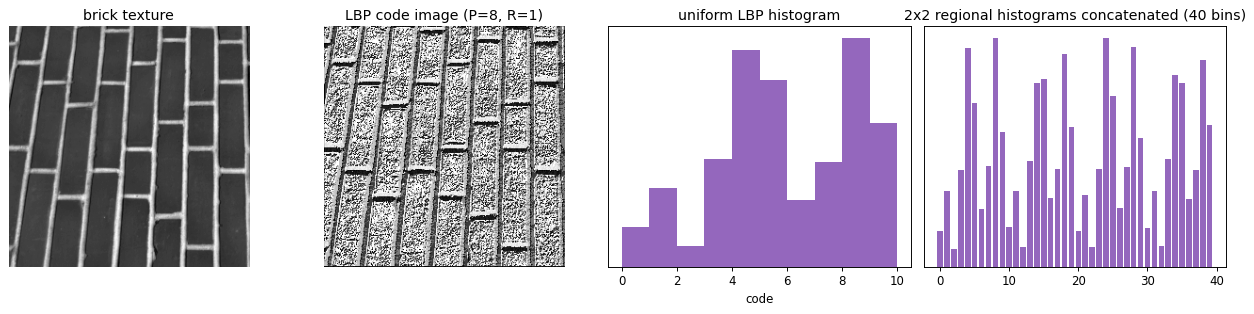

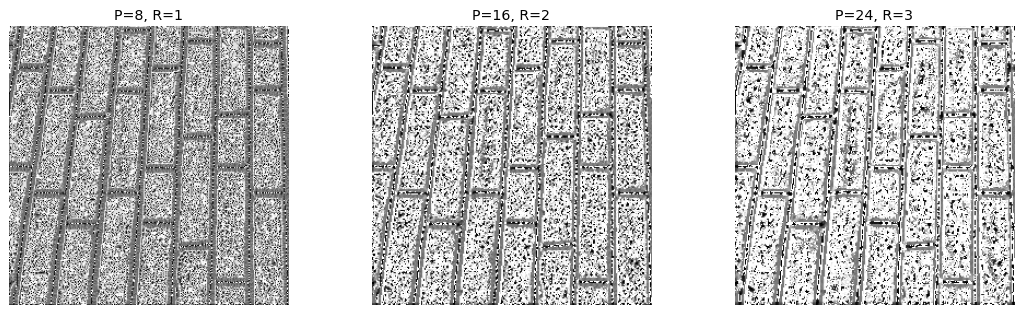

In [10]:
from skimage.feature import local_binary_pattern

tex = util.img_as_ubyte(load_gray(data.brick()))[:256, :256]  # integer image avoids interp warnings
lbp_u = local_binary_pattern(tex, P=8, R=1, method='uniform')
lbp_d = local_binary_pattern(tex, P=8, R=1, method='default')

fig, ax = plt.subplots(1, 4, figsize=(15, 3.8))
show(ax[0], tex, 'brick texture')
show(ax[1], lbp_d, 'LBP code image (P=8, R=1)')
concat = []                                                   # regional histograms, then concatenate
for by in range(2):
    for bx in range(2):
        cell = lbp_u[by * 128:(by + 1) * 128, bx * 128:(bx + 1) * 128]
        h, _ = np.histogram(cell.ravel(), bins=10, range=(0, 10))
        concat.append(h)
concat = np.concatenate(concat)
ax[2].hist(lbp_u.ravel(), bins=10, range=(0, 10), color='tab:purple')
ax[2].set_title('uniform LBP histogram'); ax[2].set_xlabel('code'); ax[2].set_yticks([])
ax[3].bar(range(len(concat)), concat, color='tab:purple')
ax[3].set_title(f'2x2 regional histograms concatenated ({len(concat)} bins)'); ax[3].set_yticks([])
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))                # radius sets the scale of texture
for k, (P, R) in enumerate([(8, 1), (16, 2), (24, 3)]):
    show(ax[k], local_binary_pattern(tex, P, R, method='uniform'), f'P={P}, R={R}')
plt.tight_layout(); plt.show()

## 6. Comparing feature detectors

Different detectors respond to different structures (corners, blobs, regions) and offer different invariances. The survey of Tuytelaars and Mikolajczyk (2008) summarizes the trade-offs. A compact version:

| Detector | Finds | Rotation inv. | Scale inv. | Affine inv. | Repeatability | Efficiency |
|---|---|:---:|:---:|:---:|:---:|:---:|
| Harris | corners | yes | no | no | high | high |
| Hessian | blobs | yes | no | no | med | med |
| Harris-Laplace | corners | yes | yes | no | high | med |
| DoG (SIFT) | blobs | yes | yes | no | med | med |
| Harris-Affine | corners | yes | yes | yes | high | med |
| Hessian-Affine | blobs | yes | yes | yes | high | med |
| MSER | regions | yes | yes | yes | high | high |

No single detector wins everywhere; the right choice depends on the transformation the images undergo and the compute budget. The demo below shows the most basic split: a corner detector (Harris) and a blob detector (DoG) firing on the same image.

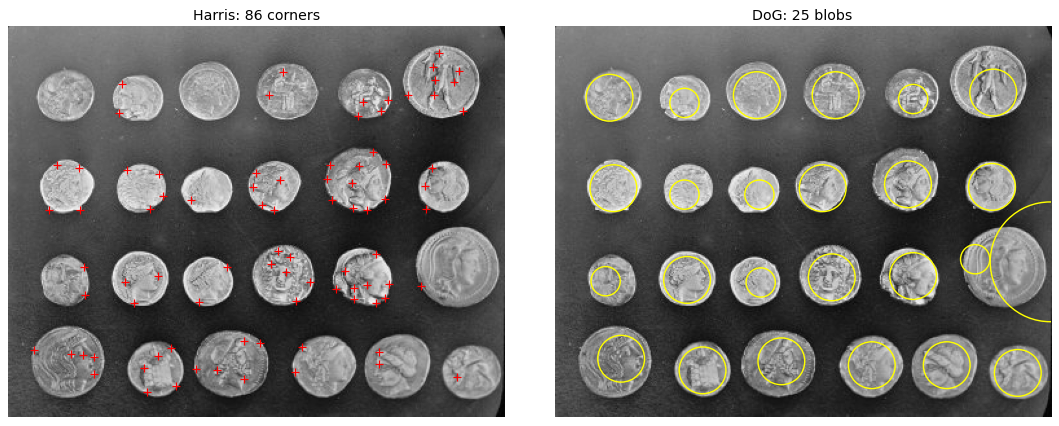

In [11]:
from skimage.feature import corner_harris, corner_peaks, blob_dog

im = util.img_as_float(data.coins())
corners = corner_peaks(corner_harris(im), min_distance=6, threshold_rel=0.02)
blobs = blob_dog(im, min_sigma=8, max_sigma=35, threshold=0.05)  # small: peak DoG response here is ~0.09

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
show(ax[0], im, f'Harris: {len(corners)} corners')
ax[0].plot(corners[:, 1], corners[:, 0], 'r+', ms=6)
show(ax[1], im, f'DoG: {len(blobs)} blobs')
for y, x, s in blobs:
    ax[1].add_patch(plt.Circle((x, y), s * np.sqrt(2), color='yellow', fill=False, lw=1.2))
plt.tight_layout(); plt.show()

---

## Key takeaways

| Descriptor | Describes | Key idea | Invariances |
|---|---|---|---|
| Shape Context | shape outline | log-polar histogram of the other boundary points, matched by chi-square | translation, scale |
| MSER | regions | connected components stable across a range of thresholds | affine, illumination |
| HOG | local shape | magnitude-weighted histogram of gradient orientations per cell, block-normalized | small deformation, contrast |
| PHOG | global and local shape | HOG over a $2^l \times 2^l$ pyramid, concatenated | adds coarse spatial layout |
| LBP | texture | histogram of per-pixel binary neighbor codes | grayscale-monotonic changes |

**Reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Ch. 4.1.1 and 4.1.2. Original papers: Belongie et al. (Shape Context, 2002), Matas et al. (MSER, 2004), Dalal and Triggs (HOG, 2005), Bosch et al. (PHOG, 2007), Ojala et al. (LBP, 1994).

**To think about:**
- All of these are *hand-designed*. What does a convolutional network learn in its early layers, and how does it compare to Gabor filters, HOG, and LBP?
- Shape Context needs a clean contour. What breaks it on a cluttered natural image?
- Why is MSER a good fit for detecting text in scenes?

## Exercises

1. **Check the HOG arithmetic.** For the Dalal-Triggs setting ($64\times128$ window, $8\times8$ cells, $2\times2$ blocks, 9 bins), derive the 3780-dimensional descriptor and confirm it against your implementation.

2. **LBP invariances.** Rotate a texture patch and compare plain LBP histograms against uniform rotation-invariant ones. Which claim of invariance actually holds?

3. **Shape Context under transformation.** Match a shape to a scaled and translated copy of itself, then to a different shape, and compare the chi-square costs.

4. **MSER stability.** Sweep the stability threshold and report how the number of detected regions responds. Which regions survive the widest range of thresholds?